# Naive Baryes Model

Load data

In [50]:
# -------------------------------------
# Load the CSV Data and summarize it
# -------------------------------------
import pandas as pd 
import numpy as np

# Load the CSV file into a DataFrame
data = pd.read_csv('../processed/combined.csv')

# -------------------------------------
# Split the data into training and testing sets: 80/20 split
# -------------------------------------
# Set a random seed for reproducibility so that the comments on the set don't need to be changed when the code is run again
random_seed = 2142026
np.random.seed(random_seed)

# generate random true (80% chance) or false values
train_index = np.random.rand(len(data)) < 0.8

# use the above list to take the training (true values)
train = data[train_index]
# the opposite (rest) is for testing
test = data[~train_index]

print(train[:5])


# -------------------------------------
# Make a list of the statuses for use later
# -------------------------------------
statuses = data['status'].unique()
print(f"\nStatuses: {statuses}")

                                           statement   status
0                                         oh my gosh  Anxiety
1  trouble sleeping, confused mind, restless hear...  Anxiety
2  all wrong, back off dear, forward doubt. stay ...  Anxiety
3  i've shifted my focus to something else but i'...  Anxiety
5  every break, you must be nervous, like somethi...  Anxiety

Statuses: ['Anxiety' 'Normal' 'Depression' 'Suicidal']


## Class distribution and Probabilities


In [51]:
def profile_statuses(data):
    # Count instances of each unique value in the 'status' column
    status_counts = data['status'].value_counts()

    # print(status_counts)

    print(f"Total statements: {len(data)}")
    for status in statuses:
        count = status_counts[status]
        prob_of_status = count / len(data)
        print(f"Status: {status}, Count: {count}, Probability: {prob_of_status:.2f}")

print("\nOverall Status Distribution:")
profile_statuses(data)
print("\nTraining Set Status Distribution:")
profile_statuses(train)
print("\nTesting Set Status Distribution:")
profile_statuses(test)


Overall Status Distribution:
Total statements: 95851
Status: Anxiety, Count: 9344, Probability: 0.10
Status: Normal, Count: 34734, Probability: 0.36
Status: Depression, Count: 29910, Probability: 0.31
Status: Suicidal, Count: 21863, Probability: 0.23

Training Set Status Distribution:
Total statements: 76709
Status: Anxiety, Count: 7462, Probability: 0.10
Status: Normal, Count: 27801, Probability: 0.36
Status: Depression, Count: 23938, Probability: 0.31
Status: Suicidal, Count: 17508, Probability: 0.23

Testing Set Status Distribution:
Total statements: 19142
Status: Anxiety, Count: 1882, Probability: 0.10
Status: Normal, Count: 6933, Probability: 0.36
Status: Depression, Count: 5972, Probability: 0.31
Status: Suicidal, Count: 4355, Probability: 0.23


## Term Probabilities

In [ ]:
import math
import matplotlib.pyplot as plt
from matplotlib import animation, rc
import pandas as pd
from IPython.display import HTML, display
from sklearn.feature_extraction.text import CountVectorizer

plt.rcdefaults()

# instantiate a count vectorizer
vect = CountVectorizer(stop_words='english')

# obtain vocabulary dictionary and return doc-term matrix
X = vect.fit_transform(train.statement) 

# get the identified terms
terms = vect.get_feature_names_out()
# terms = vect.get_feature_names()

# sum terms' frequencies in the entire collection
freqs = X.toarray().sum(axis=0)
terms = np.array(terms)
freqs = np.array(freqs)

# organize the tersm and frequencies in t and f columns
tfs = pd.DataFrame({'t':terms, 'f':freqs}, columns=['t','f'])

tfs = tfs.sort_values(by=['f'], ascending=False)
tfs = tfs.reset_index(drop=True)

In [61]:
# Show the top 10 most frequent terms
tfs['k'] = tfs.index + 1
tfs[['t','k','f']].head(5)

,t,k,f
0,to,1,237580
1,and,2,203812
2,the,3,150002
3,my,4,141996
4,it,5,116366


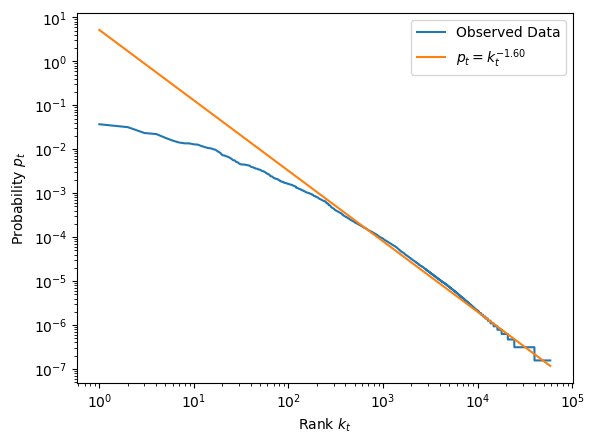

In [64]:
from sklearn.linear_model import LinearRegression
tfs['k'] = tfs.index + 1

ttf = tfs['f'].sum()
tfs['p'] = tfs['f'] / ttf

# log transformation of k and p values
x = tfs['k'].values.reshape(-1,1)
xlog = np.log(x)
y = tfs['p'].values.reshape(-1,1)
ylog = np.log(y)

# perform linear regression on log values
lm = LinearRegression()
lm.fit(xlog,ylog)
yplog = lm.predict(xlog)

# plot the fitted (predicted) line 
# along with actual k_t and p_t data
plt.loglog(tfs['k'], tfs['p'], label="Observed Data")
plt.loglog(x, np.exp(yplog), 
           label="$p_t = k_t^{" + "{:.2f}".format(lm.coef_[0][0]) + "}$")
plt.xlabel('Rank $k_t$')
plt.ylabel('Probability $p_t$')
plt.legend()
plt.show()

## Text Vectorization

In [65]:
# instantiate a count vectorizer
test_vect = CountVectorizer(stop_words='english')

train_fit_transform = test_vect.fit_transform(train.statement)

features = test_vect.get_feature_names_out()
print(features[:10])

test_transform = test_vect.transform(test.statement)
features_test = test_vect.get_feature_names_out()
print(features_test[:10])

['00' '000' '0000' '00000' '000000' '000000000' '00000062' '000002'
 '00001' '0001']
['00' '000' '0000' '00000' '000000' '000000000' '00000062' '000002'
 '00001' '0001']


## Construct Probabilistic Naive Bayes Model 

In [66]:
from sklearn.naive_bayes import MultinomialNB

alpha = 0.9
bnb = MultinomialNB(alpha=alpha)
bnb.fit(train_fit_transform, train.status)
v1p = bnb.predict(test_transform)
print(v1p[:10])

['Anxiety' 'Depression' 'Depression' 'Anxiety' 'Anxiety' 'Anxiety'
 'Anxiety' 'Anxiety' 'Anxiety' 'Depression']


['Anxiety' 'Depression' 'Depression' 'Anxiety' 'Anxiety' 'Anxiety'
 'Anxiety' 'Anxiety' 'Anxiety' 'Depression']


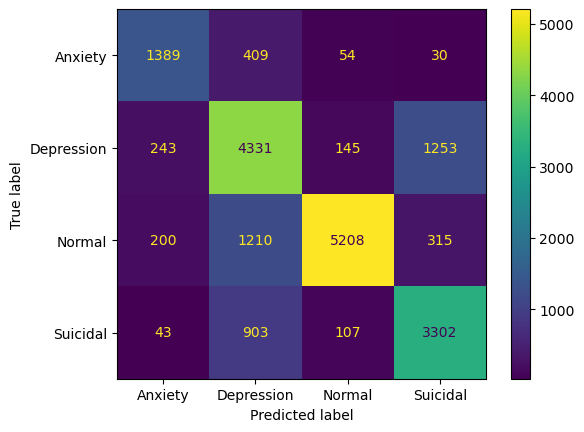

In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
test_predict = bnb.predict(test_transform)
print(test_predict[:10])

ConfusionMatrixDisplay.from_predictions(test.status, 
                                        test_predict,
                                        display_labels=bnb.classes_)

In [68]:

for status in statuses:
    predicted_count = np.sum(test_predict == status)
    actual_count = np.sum(test.status == status)
    false_predictions = np.sum((test.status == status) & (test_predict != status))
    print(f"Status: {status}, Predicted Count: {predicted_count}, Actual Count: {actual_count}")

    percent_false_predictions = (false_predictions/predicted_count) * 100
    print(f"    Percent of false predictions for {status}: {percent_false_predictions:.2f}%")

    for status2 in statuses:
        count = np.sum((test.status == status) & (test_predict == status2))
        print(f"    Predicted as {status2}: {count}")



Status: Anxiety, Predicted Count: 1875, Actual Count: 1882
    Percent of false predictions for Anxiety: 26.29%
    Predicted as Anxiety: 1389
    Predicted as Normal: 54
    Predicted as Depression: 409
    Predicted as Suicidal: 30
Status: Normal, Predicted Count: 5514, Actual Count: 6933
    Percent of false predictions for Normal: 31.28%
    Predicted as Anxiety: 200
    Predicted as Normal: 5208
    Predicted as Depression: 1210
    Predicted as Suicidal: 315
Status: Depression, Predicted Count: 6853, Actual Count: 5972
    Percent of false predictions for Depression: 23.95%
    Predicted as Anxiety: 243
    Predicted as Normal: 145
    Predicted as Depression: 4331
    Predicted as Suicidal: 1253
Status: Suicidal, Predicted Count: 4900, Actual Count: 4355
    Percent of false predictions for Suicidal: 21.49%
    Predicted as Anxiety: 43
    Predicted as Normal: 107
    Predicted as Depression: 903
    Predicted as Suicidal: 3302


In [69]:
from sklearn.metrics import accuracy_score, cohen_kappa_score 
acc = accuracy_score(v1p, test.status)
kappa = cohen_kappa_score(v1p, test.status)

print("Accuracy: {:.4f}".format(acc))
print("Kappa   : {:.4f}".format(kappa))

# Calculate the ROC AUC score
# from sklearn.metrics import roc_auc_score
# roc_auc = roc_auc_score(test.status.map({this_status: index for index, this_status in enumerate(statuses)}), 
#                         bnb.predict_proba(test_transform)[:, 1])
# print("ROC AUC Score: {:.4f}".format(roc_auc))

Accuracy: 0.7434
Kappa   : 0.6417


In [70]:
trial_value=["always restless every night, even though i don't know why, what's wrong. strange.",
            "because this worry is you.",
            "hi, i want to tell you... lately i've been feeling restless, have trouble sleeping, i searched on google it says it's a mild symptom of depression, i used to tell my mom a psychologist friend ""don't think too much, it's not important you get depressed easily"" then i frequent irregular breathing.",

            "i just woke up listening to nct dream 1.71 million seller, i immediately woke up, i thought i was still dreaming",
            "you don't have to complicate things anymore, people",
            "i am your cousin",

            "i recently went through a breakup and she said she still wants to be friends so i said i can try doing that but when she talks to me about things it always hurts. i just want to lose feelings so all this pain can stop it hurts so much and i cannot even cry about it. i do not want to hurt her because she said she does not want to never speak to me again but i do not know what to do here. when we were together she always hurt me so i do not know why i still love her. i wish we never met it would be much less painful how do i lose feelings?",
            "i do not know how to navigate these feelings, not that its a new feeling by any stretch. i just do not understand how i can go on from being so pleasantly fine to suicidal and self loathing within in minutes and not be able to step out of it. i have been suffering from poor mental health for over 10 years and i am about to turn 26 next week and i feel so ashamed for how serious my negative thoughts are. covid was a hard transition especially having moved to a new city a few months before everything started locking down, but now i am here and settled and i have a loving partner, a great connection to their family, a really fun job and i finished my degree. but when i stop and look around i feel like nothing will ever be good enough for me and i will never be good enough, i will always have skin problems and bad teeth and acne. i will never be the artist i used to be (i have a bachelor in fine art) because i do not have the same drive or passionate that i used to have for it. i will never have the career i built my entire plan around because i am losing my interest in art. i will never have the relationship with my family that i want because i could not stand to stay in my hometown. all i can feel is this tornado of my failures swirling around me all the damn time. it just seems that no matter how many positives come my way they do not last long enough to out weight the negatives. i do not really know what i am looking for i guess i just wanted to say this out loud, or whatever. 0 to 100",
            "so i have been with my bf for 5 months , and he already told me he was depressed. to this week nothing particular happened, but i can now feel hes bothered by it. he does not ask me to sleep together, do things and etci know i am not the problem i am aware of that, i just wanted to ask: how can i be there without suffocating him? i am really clingy, a thing which he usually loves about me but right now i kind of have a feeling that i am doing too much.any suggestion will be gladly accepted, be frank and tell me how i can not make it worse: its that that bothers me. my bf (21) is having a bad time due to his depression",

            "there is.....foodand other things i will be judged for and for having weird views because maybe i am delusional i want to go to jail. life would be better there i am not joking. maybe suicide would not even cross my mind in jail",
            "anyone know of a way that has no chance of failure, is decently quick and is not a gun? it would be much appreciated painless way except gun?",
            "if i find out i have another illness on top of my epilepsy i will end my life. i am done. i am fucking done. if i find out i have something else"
            ]
should_be=['Anxiety', 'Anxiety', 'Anxiety', 'Normal','Normal','Normal', 'Depression','Depression','Depression','Suicidal','Suicidal','Suicidal']
trial_transform = test_vect.transform(trial_value)

result = bnb.predict(trial_transform)
print(f"result: {result}")
print(f"should be: {should_be}")


result: ['Anxiety' 'Anxiety' 'Anxiety' 'Normal' 'Depression' 'Normal' 'Suicidal'
 'Depression' 'Depression' 'Suicidal' 'Suicidal' 'Suicidal']
should be: ['Anxiety', 'Anxiety', 'Anxiety', 'Normal', 'Normal', 'Normal', 'Depression', 'Depression', 'Depression', 'Suicidal', 'Suicidal', 'Suicidal']


In [71]:
# One at a time
single_value = ["hi, i want to tell you... lately i've been feeling restless, have trouble sleeping, i searched on google it says it's a mild symptom of depression, i used to tell my mom a psychologist friend ""don't think too much, it's not important you get depressed easily"" then i frequent irregular breathing."]

single_transform = test_vect.transform(single_value)
single_result = bnb.predict(single_transform)
print(f"single result (expect Anxiety): {single_result}")


single result (expect Anxiety): ['Anxiety']


## Pickle the model for future use


In [72]:
import pickle

# Save the model to a file
with open('naive_bayes_model.pkl', 'wb') as file:
    pickle.dump(bnb, file)